# 05 — Support Vector Machine (SVM)

**O que é:** algoritmo que encontra o hiperplano de margem máxima que separa as classes no espaço de features.

**Kernel RBF (Radial Basis Function):** transforma os dados em espaço de alta dimensão para tornar separáveis casos não-lineares.

**Vantagens:** eficiente em espaços de alta dimensão, robusto quando número de features > amostras.

**Desvantagens:** lento para grandes datasets, difícil de interpretar, sensível à escala (por isso normalizamos os dados).

## Carregamento e Preparação (igual aos notebooks anteriores)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import joblib
from IPython.display import Image, display
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay
)

FEATURES = ['Plantel', 'Estrangeiros', 'Valor de Mercado Total']
TARGET   = 'Status_bin'

df = pd.read_excel(os.path.join('..', 'dados', 'BASE_FINAL.xlsx'), sheet_name='CLUBES')
df.columns = df.columns.str.strip()
df[TARGET] = df['Situacao'].apply(lambda x: 1 if str(x).strip().lower() == 'rebaixado' else 0)

df_rot = df[df['Temporada'] < 2025].copy()
df_tr  = df_rot[df_rot['Temporada'] <= 2022]
df_te  = df_rot[df_rot['Temporada']  > 2022]

scaler = StandardScaler()
X_tr = scaler.fit_transform(df_tr[FEATURES])
y_tr = df_tr[TARGET].values
X_te = scaler.transform(df_te[FEATURES])
y_te = df_te[TARGET].values

print(f'Treino: {X_tr.shape} | Teste: {X_te.shape}')

Treino: (180, 3) | Teste: (40, 3)


## Treinamento do SVM

Usamos kernel RBF (padrão), `class_weight='balanced'` e `probability=True` para obter probabilidades.

In [2]:
svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm.fit(X_tr, y_tr)

print('Modelo treinado com sucesso!')
print(f'Classes: {svm.classes_}  (0=Permaneceu, 1=Rebaixado)')
print(f'Kernel: {svm.kernel} | C: {svm.C} | Gamma: {svm.gamma}')
print(f'Vetores de suporte: {svm.n_support_}  (por classe)')

Modelo treinado com sucesso!
Classes: [0 1]  (0=Permaneceu, 1=Rebaixado)
Kernel: rbf | C: 1.0 | Gamma: scale
Vetores de suporte: [92 25]  (por classe)


## Avaliação no Conjunto de Teste

Acuracia no teste: 0.7750 (77.50%)

Relatorio de Classificacao:
              precision    recall  f1-score   support

  Permaneceu       0.81      0.94      0.87        32
   Rebaixado       0.33      0.12      0.18         8

    accuracy                           0.78        40
   macro avg       0.57      0.53      0.53        40
weighted avg       0.72      0.78      0.73        40



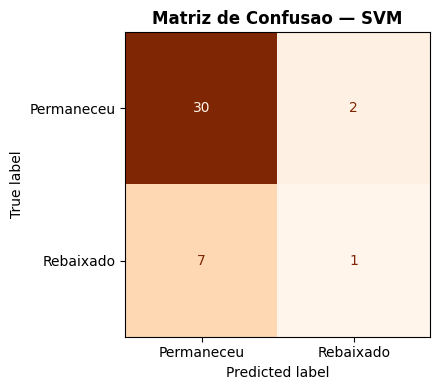

In [3]:
y_pred = svm.predict(X_te)
acc = accuracy_score(y_te, y_pred)
print(f'Acuracia no teste: {acc:.4f} ({acc*100:.2f}%)')
print()
print('Relatorio de Classificacao:')
print(classification_report(y_te, y_pred, target_names=['Permaneceu', 'Rebaixado']))

os.makedirs(os.path.join('..', 'img'), exist_ok=True)
cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Permaneceu', 'Rebaixado'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Matriz de Confusao — SVM', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('..', 'img', 'cm_svm.png'), dpi=150)
plt.show()

## Curva ROC e AUC

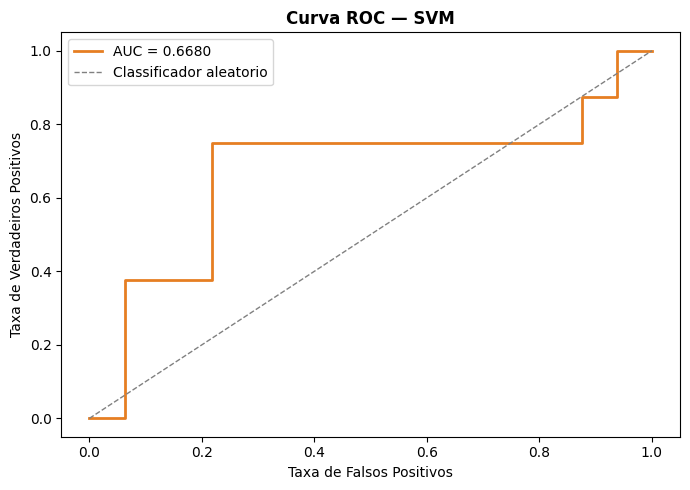

AUC: 0.6680


In [4]:
y_prob = svm.predict_proba(X_te)[:, 1]
fpr, tpr, _ = roc_curve(y_te, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#e67e22', lw=2, label=f'AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Classificador aleatorio')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC — SVM', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join('..', 'img', 'roc_svm.png'), dpi=150)
plt.show()
print(f'AUC: {roc_auc:.4f}')

## Probabilidades por Clube no Conjunto de Teste

In [5]:
probs = svm.predict_proba(X_te)
idx_reb = list(svm.classes_).index(1)

df_res = df_te[['Clube', 'Temporada']].copy()
df_res['Prob_Rebaixamento(%)'] = (probs[:, idx_reb] * 100).round(2)
df_res['Real']     = y_te
df_res['Previsto'] = svm.predict(X_te)
df_res = df_res.sort_values('Prob_Rebaixamento(%)', ascending=False)

print('Probabilidades de rebaixamento (conjunto de teste):')
df_res

Probabilidades de rebaixamento (conjunto de teste):


,Clube,Temporada,Prob_Rebaixamento(%),Real,Previsto
219,Juventude,2024,46.82,0,1
217,Vitoria,2024,38.47,0,1
198,Goias,2023,36.99,1,1
215,Atletico Goianiense,2024,16.54,1,0
197,America Mineiro,2023,15.56,1,0
199,Cuiaba,2023,12.94,0,0
193,Cruzeiro,2023,12.90,0,0
191,Vasco da Gama,2023,11.70,0,0
200,Flamengo,2024,11.61,0,0
192,Bahia,2023,10.79,0,0


## Salvando o Modelo

In [6]:
os.makedirs(os.path.join('..', 'modelos'), exist_ok=True)
joblib.dump(svm,    os.path.join('..', 'modelos', 'svm.pkl'))
joblib.dump(scaler, os.path.join('..', 'modelos', 'scaler_svm.pkl'))
print('Modelo salvo em modelos/svm.pkl')
print('Scaler salvo em modelos/scaler_svm.pkl')

Modelo salvo em modelos/svm.pkl
Scaler salvo em modelos/scaler_svm.pkl


## Interpretação e Comparação

Descreva os resultados obtidos pelo SVM e compare com os modelos anteriores.

**Pontos a observar:**
- O SVM com kernel RBF pode capturar fronteiras de decisão não-lineares, o que pode ser uma vantagem sobre a Regressão Logística.
- Por não fornecer coeficientes diretos, a interpretabilidade é menor do que a Regressão Logística.
- O número de vetores de suporte indica a complexidade da fronteira aprendida: muitos vetores podem indicar overfitting.
- Com dados normalizados (StandardScaler), o SVM tende a ter desempenho mais estável.
- Compare AUC, precision e recall para a classe minoritária (Rebaixado) entre os três modelos treinados.